In [1]:
from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import mdtraj as md

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
def add_ordinal_suffix(n):
    """
    Add the appropriate ordinal suffix ('st', 'nd', 'rd', 'th') to an integer.

    Args:
        n (int): The integer to which the ordinal suffix should be added.

    Returns:
        str: The integer as a string with the appropriate ordinal suffix.
    """
    # Handle special cases for 11, 12, 13
    if 10 <= n % 100 <= 13:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    
    return f"{n}{suffix}"

In [3]:
def dir_to_trj(path, calpha_only=False):
    
    pdb_list = glob(path + '/*.pdb')
    print('found %d hit pdbs' % len(pdb_list))

    structures = None
    cells = []
    
    for pdb in tqdm(pdb_list):

        try:

            trj = md.load_pdb(pdb)
            if calpha_only:
                idx = trj.top.select('(type != H) and is_protein and (name == CA)')
            else:
                idx = trj.top.select('(type != H) and is_protein')
            trj = trj.atom_slice(idx)

            if structures:
                structures = structures.join(trj)
            else:
                structures = trj

        except Exception as e:
            print(pdb, e)
            print(trj.n_atoms, structures.n_atoms)

    structures = structures.center_coordinates()
    print('final num loaded:', len(structures))

    return structures

In [4]:
SELECTED_DATASET_PDBS = '/Users/tjlane/Desktop/selected_dataset_archive_2024-08-07/pdb'
apo_calpha = dir_to_trj(SELECTED_DATASET_PDBS, calpha_only=True)
apo_all = dir_to_trj(SELECTED_DATASET_PDBS, calpha_only=False)

found 1146 hit pdbs


100%|██████████| 1146/1146 [01:38<00:00, 11.66it/s]


final num loaded: 1146
found 1146 hit pdbs


100%|██████████| 1146/1146 [01:54<00:00,  9.98it/s]

final num loaded: 1146


In [5]:
def all_to_all_rmsd(trj):
    result = []
    for j in range(trj.n_frames):
        rmsds = md.rmsd(trj, trj[j], precentered=False) * 10.0
        result.extend(rmsds)
    return np.array(result)

In [6]:
mean_structure = apo_calpha[0]
mean_structure.xyz[0] = apo_calpha.xyz.mean(axis=0)

per_atom_per_xyz_std = np.std(apo_calpha.xyz * 10.0, axis=0)  # mdtraj uses nm
per_atom_average_std = np.mean(per_atom_per_xyz_std, axis=1)

calpha_all_to_all_rmsd = all_to_all_rmsd(apo_calpha)

print(apo_calpha.xyz.shape, per_atom_average_std.shape, calpha_all_to_all_rmsd.shape)

(1146, 306, 3) (306,) (1313316,)


In [7]:
mean_structure_all_atom = apo_all[0]
mean_structure_all_atom.xyz[0] = apo_all.xyz.mean(axis=0)

per_atom_per_xyz_std_all_atom = np.std(apo_all.xyz * 10.0, axis=0)  # mdtraj uses nm
per_atom_average_std_all_atom = np.mean(per_atom_per_xyz_std_all_atom, axis=1)

all_atom_all_to_all_rmsd = all_to_all_rmsd(apo_all)

print(apo_all.xyz.shape, per_atom_average_std_all_atom.shape, all_atom_all_to_all_rmsd.shape)

(1146, 2367, 3) (2367,) (1313316,)


In [8]:
number_atoms_to_show = 6
subsample_factor = len(per_atom_average_std) // number_atoms_to_show
atoms_shown = [i * subsample_factor + 1 for i in range(number_atoms_to_show)]

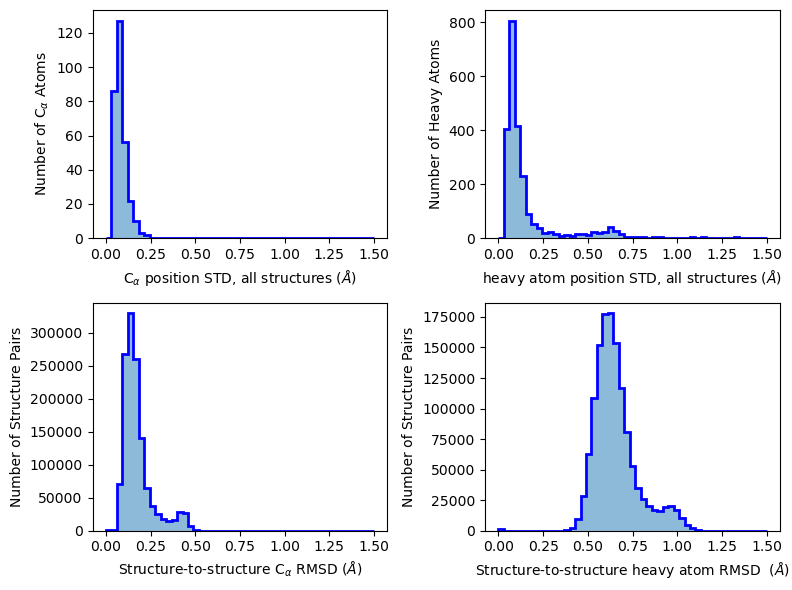

In [11]:
bins = np.linspace(0.0, 1.5, 50)

plt.figure(figsize=(8,6))

plt.subplot(221)
plt.hist(per_atom_average_std, alpha=0.5, lw=2, bins=bins)
plt.hist(per_atom_average_std, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"C$_\alpha$ position STD, all structures ($\AA$)")
plt.ylabel(r"Number of C$_\alpha$ Atoms")

plt.subplot(222)
plt.hist(per_atom_average_std_all_atom, alpha=0.5, lw=2, bins=bins)
plt.hist(per_atom_average_std_all_atom, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"heavy atom position STD, all structures ($\AA$)")
plt.ylabel(r"Number of Heavy Atoms")

plt.subplot(223)
plt.hist(calpha_all_to_all_rmsd, alpha=0.5, lw=2, bins=bins)
plt.hist(calpha_all_to_all_rmsd, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"Structure-to-structure C$_\alpha$ RMSD ($\AA$)")
plt.ylabel(r"Number of Structure Pairs")

plt.subplot(224)
plt.hist(all_atom_all_to_all_rmsd, alpha=0.5, lw=2, bins=bins)
plt.hist(all_atom_all_to_all_rmsd, histtype='step', lw=2, color='blue', bins=bins)
plt.xlabel(r"Structure-to-structure heavy atom RMSD  ($\AA$)")
plt.ylabel(r"Number of Structure Pairs")

plt.tight_layout()
plt.savefig("./displacement_summary.png")
plt.show()

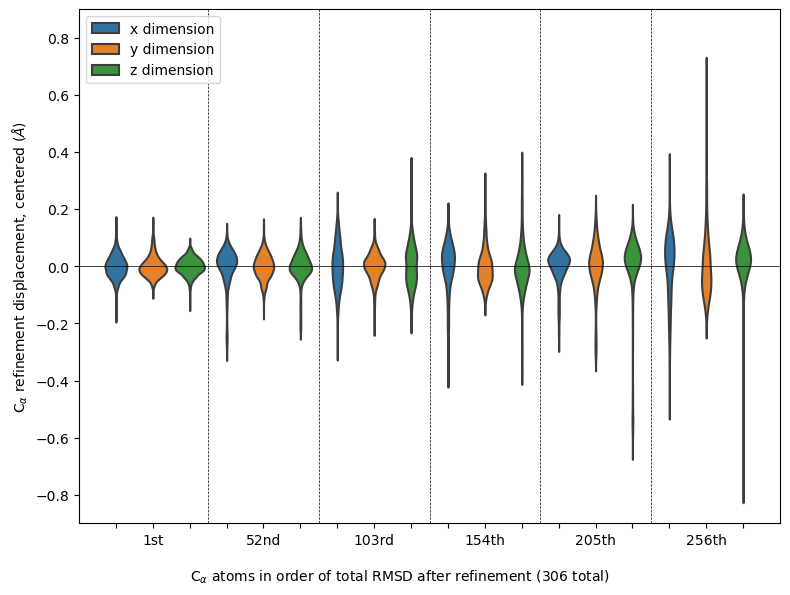

In [10]:
# compute an array that is (samples, n_atoms*3), where the 3 is x/y/z
# sorted by the atom's RMSD in the ensemble... ie less mobile atoms during refinement 
# to the left, more mobile to the right
sorted_xyz = apo_calpha.xyz[:,np.argsort(per_atom_average_std),:][:,::subsample_factor,:]  * 10.0 # dont forget unit conversion
sorted_xyz = sorted_xyz.reshape(sorted_xyz.shape[0], -1)
sorted_xyz -= sorted_xyz.mean(axis=0)[None,:]

xyz_data = pd.DataFrame(sorted_xyz)

# -----------------------------

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

sns.violinplot(
    data=xyz_data,
    inner=None,
    palette=colors,
)

ax.legend(["x dimension", "y dimension", "z dimension"], loc=2)
ax.set_ylabel(r"C$_\alpha$ refinement displacement, centered ($\AA$)")

xticklabels = []
for atom_shown in atoms_shown:
    xticklabels.extend(["", f"{add_ordinal_suffix(atom_shown)}", ""] )
ax.set_xticklabels(
    xticklabels
)

bottom_label = r"C$_\alpha$ atoms in order of total RMSD after refinement (306 total)"
ax.text(2, -1.1, bottom_label)

ylim = 0.9
for n in range(number_atoms_to_show-1):
    plt.vlines(n*3+2.5, -ylim, ylim, color='k', linestyle="--", lw=0.5)
ax.set_ylim([-ylim, ylim])

ax.hlines(0.0, -2, number_atoms_to_show*3+1, color="k", lw=0.5)
ax.set_xlim([-1, number_atoms_to_show*3])

plt.tight_layout()
plt.savefig("./per-dimension-atom-position-distributions.png")
plt.show()